<a href="https://colab.research.google.com/github/himavaishnavi3/Waste-Classification/blob/main/Waste_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Google Drive Integration

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Dataset Path Configuration

In [2]:
train_dir = "/content/drive/MyDrive/RealWaste"
test_dir = "/content/drive/MyDrive/RealWaste"

#Dataset Verification

In [3]:
import os

print(os.listdir(train_dir))
print(os.listdir(test_dir))

['Plastic', 'Glass', 'Paper', 'Metal', 'Food Organics']
['Plastic', 'Glass', 'Paper', 'Metal', 'Food Organics']


#Import Libraries

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

#Data Preprocessing and Augmentation

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

#Dataset Loading

In [6]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

num_classes = train_data.num_classes

Found 3042 images belonging to 5 classes.
Found 3042 images belonging to 5 classes.


#MobileNetV2 Model Initialization

In [7]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Custom Classification Layer Construction

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

#Model Compilation

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Model Training

In [10]:
optimizer = tf.keras.optimizers.Adam()
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 949s 10s/step - accuracy: 0.7252 - loss: 0.7300 - val_accuracy: 0.8320 - val_loss: 0.4347
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 771ms/step - accuracy: 0.8218 - loss: 0.4458 - val_accuracy: 0.8287 - val_loss: 0.4255
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 759ms/step - accuracy: 0.8669 - loss: 0.3595 - val_accuracy: 0.8872 - val_loss: 0.3028
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 761ms/step - accuracy: 0.8810 - loss: 0.3086 - val_accuracy: 0.8774 - val_loss: 0.3070
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 750ms/step - accuracy: 0.8925 - loss: 0.2800 - val_accuracy: 0.9053 - val_loss: 0.2453
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 753ms/step - accuracy: 0.9057 - loss: 0.2455 - val_accuracy: 0.8892 - val_loss: 0.2937
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 770ms/step - accuracy: 0.9155 - loss: 0.2364 - val_accuracy: 0.8455 - val_loss: 0.3587
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 769ms/step - accuracy: 0.9172 - loss: 0.2297 - val_accur

#Model Evaluation using Confusion Matrix

96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 247ms/step


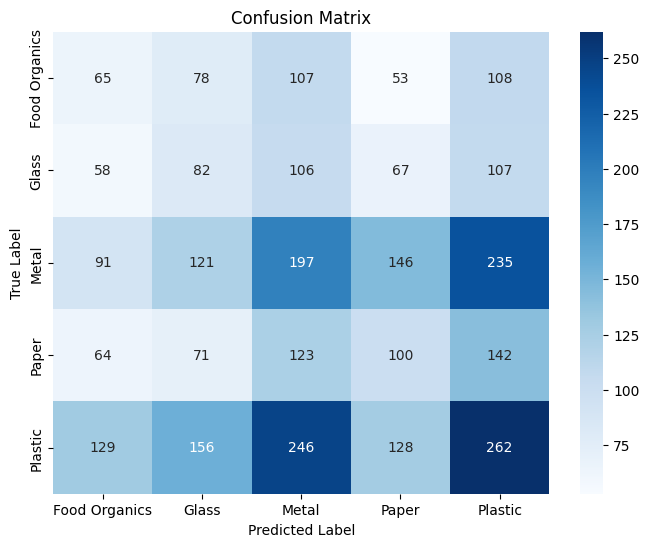

In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
predictions = model.predict(test_data)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = test_data.classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_data.class_indices.keys()),
    yticklabels=list(test_data.class_indices.keys())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

#Model Saving

In [12]:
model.save("waste_mobilenet.h5")

#Model Loading

In [13]:
model = tf.keras.models.load_model("waste_mobilenet.h5")
class_names = list(train_data.class_indices.keys())

#Waste Prediction Function

In [14]:
def predict_waste(img):
    img = img.resize((224, 224))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    return class_names[class_index]

#Gradio User Interface Development

In [15]:
import gradio as gr
import numpy as np
import tensorflow as tf

# Load model
model = tf.keras.models.load_model("waste_mobilenet.h5")

# Class names (same order as training)
class_names = [
    "Food Organics",
    "Glass",
    "Metal",
    "Paper",
    "Plastic",
    "Cardboard"
]

# Prediction function
def predict_waste(img):
    img = img.resize((224, 224))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0]

    class_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    return f"{class_names[class_index]} ({confidence:.2f}%)"

# Gradio Interface
interface = gr.Interface(
    fn=predict_waste,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="♻️ Smart Waste Classification System",
    description="Upload a waste image to identify its category."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5c50f18257d5320ebe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
